# QF632 Financial Data Science — Milestone 3
## Methodological Selection & Diagnostic Checks
### Group 4 | Predicting TTF–HH / TTF–JKM Spreads

**Pipeline summary**
1. Rolling z-score features on train window  
2. Fit PCA on train features (price legs excluded)  
3. Scree / elbow → choose K components  
4. PCR: OLS (spread ~ PC1…PCK) with HC3 standard errors  
5. Regression diagnostics: residual scatter, Breusch-Pagan, Durbin-Watson, ACF  
6. Multicollinearity check (VIF on PCs — sanity; VIF on raw features for motivation)  
7. Chow structural-break tests at known dates (2022-02-24 invasion, 2026-01-01 Iran)  
8. Out-of-sample projection onto 2026 test window

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Aesthetic ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

# ── Key dates ────────────────────────────────────────────────────────────────
TRAIN_END   = '2025-12-31'
TEST_START  = '2026-01-01'
UKRAINE_DATE = '2022-02-24'
IRAN_DATE    = '2026-01-01'
TRANSIT_HALT = '2025-01-01'   # Russian transit to zero

REGIME_COLORS = {
    'normal':  '#4c72b0',
    'covid':   '#dd8452',
    'ukraine': '#c44e52',
    'iran':    '#8172b3',
}

print('Imports OK')

Imports OK


## 1. Load Data & Reproduce M2 Alignment

In [2]:
# ── Load master panel (native units) ─────────────────────────────────────────
df = pd.read_csv('data/master_panel_daily.csv', index_col=0, parse_dates=True)
df.index.name = 'date'
print(f'Panel loaded: {df.shape[0]} rows × {df.shape[1]} cols  |  '
      f'{df.index.min().date()} → {df.index.max().date()}')
print('Regimes:', df['regime'].value_counts().to_dict())

Panel loaded: 1934 rows × 31 cols  |  2019-01-02 → 2026-06-01
Regimes: {'ukraine': 1047, 'normal': 582, 'covid': 239, 'iran': 66}


### 1.1 Feature selection — exclude price legs to prevent leakage

Price legs (TTF, HH, JKM in any form) are *components* of the spread targets.
Including them as features would be circular: the model would just reconstruct
the spread from its own parts rather than learning fundamental drivers.

In [3]:
# Columns to DROP from feature set (price legs + derived spreads + regime label)
PRICE_LEGS = [
    'ttf_eur_mwh', 'ttf_usd',          # TTF (both units)
    'hh_fut_usd_mmbtu',                  # Henry Hub futures
    'henry_hub_spot_usd_mmbtu',          # Henry Hub spot
    'jkm_usd_mmbtu',                     # JKM
    'eu_gas_twh',                        # redundant storage twin
    'GPRC_RUS',                          # country-specific, regime-inconsistent
]
TARGETS     = ['spread_ttf_hh', 'spread_ttf_jkm', 'spread_jkm_hh']
DROP_COLS   = PRICE_LEGS + TARGETS + ['regime']

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f'{len(FEATURE_COLS)} features selected:')
print(FEATURE_COLS)

20 features selected:
['brent_usd_bbl', 'usdcny', 'eurusd', 'carbon_grn_usd', 'eu_storage_pct', 'eu_lng_sendout_gwh', 'ru_velke_kapusany_kwh_d', 'wind_northsea_kmh', 'hdd_amsterdam', 'hdd_chicago', 'hdd_seoul', 'us_working_gas_bcf', 'us_ip_index', 'euro_ip_index', 'kr_ip_yoy', 'GPR', 'GPRT', 'GPRA', 'epu_europe', 'brent_usd_mmbtu']


### 1.2 Train / test split

In [4]:
train_mask = df.index <= TRAIN_END
test_mask  = df.index >= TEST_START

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy()

print(f'Train: {df_train.shape[0]} days  ({df_train.index.min().date()} – {df_train.index.max().date()})')
print(f'Test:  {df_test.shape[0]} days  ({df_test.index.min().date()} – {df_test.index.max().date()})')

Train: 1826 days  (2019-01-02 – 2025-12-31)
Test:  108 days  (2026-01-01 – 2026-06-01)


## 2. Rolling Z-Score Features (train window only)

Window = 252 business days (≈1 year).  
EU storage % is already a bounded 0–1 ratio — kept as-is, not z-scored.  
Scaler is fit on train, applied to test. Targets remain in native USD/MMBtu.

In [5]:
ROLL_WINDOW = 252
BOUNDED_COLS = ['eu_storage_pct']   # keep ÷100, do not z-score

def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    """Trailing rolling z-score. Each day uses only its own past."""
    mu  = series.shift(1).rolling(window, min_periods=60).mean()
    sig = series.shift(1).rolling(window, min_periods=60).std()
    return (series - mu) / sig.replace(0, np.nan)

# Apply rolling z on full series (rolling uses only past, so no leakage)
df_feat = pd.DataFrame(index=df.index)
for col in FEATURE_COLS:
    if col in BOUNDED_COLS:
        df_feat[col] = df[col] / 100.0           # 0–1 ratio
    else:
        df_feat[col] = rolling_zscore(df[col], ROLL_WINDOW)

# Special case: Russian pipeline (ru_velke_kapusany_kwh_d) becomes structurally
# zero after the 2025 transit halt.  When the rolling window is all-zero the
# std = 0 → z-score = NaN, but those NaNs encode a real physical signal (zero
# flow), not missing data.  Per M2 §3.1 we keep structural zeros as values;
# here we map them to z = 0 ("at the new regime mean of zero").
if 'ru_velke_kapusany_kwh_d' in df_feat.columns:
    raw_zero = (df['ru_velke_kapusany_kwh_d'] == 0)
    df_feat.loc[raw_zero, 'ru_velke_kapusany_kwh_d'] = 0.0

# Split after scaling
X_train_raw = df_feat[train_mask].copy()
X_test_raw  = df_feat[test_mask].copy()

# Drop rows with too many NaNs (opening lead-in for monthly series)
# Strategy: drop rows where >40% of features are NaN
thresh = int(0.6 * len(FEATURE_COLS))
X_train_clean = X_train_raw.dropna(thresh=thresh)

# For remaining NaNs, forward-fill within train (same rule as M2)
X_train_clean = X_train_clean.ffill()
# Drop any residual NaNs that couldn't be forward-filled (very first rows)
X_train_clean = X_train_clean.dropna()

X_test_clean = X_test_raw.ffill().dropna()

# Align targets
y_train = df.loc[X_train_clean.index, TARGETS]
y_test  = df.loc[X_test_clean.index,  TARGETS]

print(f'X_train: {X_train_clean.shape}  |  X_test: {X_test_clean.shape}')
print(f'y_train: {y_train.shape}        |  y_test: {y_test.shape}')

X_train: (1222, 20)  |  X_test: (108, 20)
y_train: (1222, 3)        |  y_test: (108, 3)


## 3. PCA — Fit on Train

PCA reduces collinear drivers (GPR/GPRT/GPRA ≈ 0.9, US–EU IP 0.57–0.82)
into orthogonal factors. We fit a full PCA then choose K via the scree plot.

In [6]:
# Step 1: StandardScaler fit on train (PCA wants zero-mean unit-variance input;
# most features are already rolling-z but bounded col and any residual scale drift
# justify a final pass)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train_clean)
X_te_scaled = scaler.transform(X_test_clean)

# Step 2: Full PCA on train
pca_full = PCA()
pca_full.fit(X_tr_scaled)

evr      = pca_full.explained_variance_ratio_
cum_evr  = np.cumsum(evr)
n_components_full = len(evr)

print(f'Total components: {n_components_full}')
print('Cumulative variance explained:')
for k in [3,4,5,6,7,8,10]:
    if k <= n_components_full:
        print(f'  PC1–PC{k:2d}: {cum_evr[k-1]*100:.1f}%')

Total components: 20
Cumulative variance explained:
  PC1–PC 3: 51.4%
  PC1–PC 4: 61.0%
  PC1–PC 5: 69.4%
  PC1–PC 6: 76.0%
  PC1–PC 7: 80.4%
  PC1–PC 8: 84.8%
  PC1–PC10: 90.6%


### 3.1 Scree Plot — elbow selection

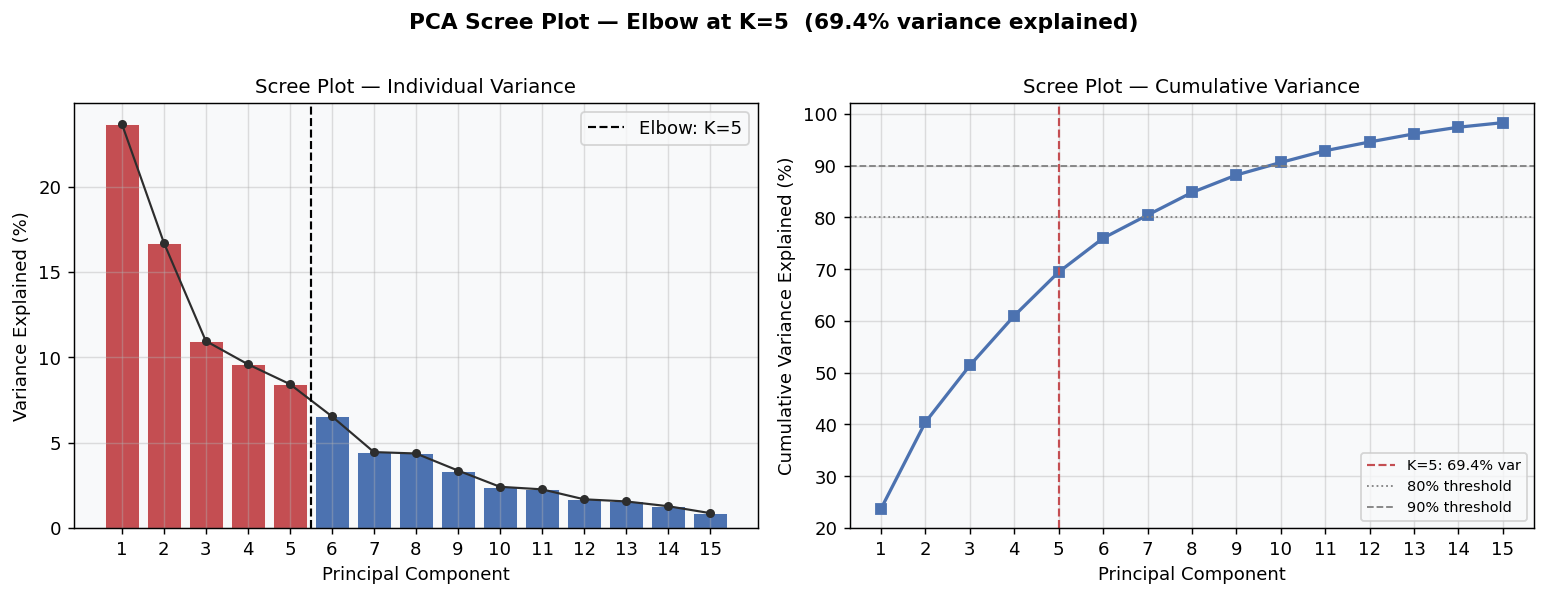

Chosen K=5, cumulative variance = 69.4%


In [7]:
K_CHOSEN = 5   # ← adjust after inspecting the scree plot below

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: individual variance explained ──────────────────────────────────────
ax = axes[0]
n_show = min(15, n_components_full)
bars = ax.bar(range(1, n_show+1), evr[:n_show]*100,
              color=['#c44e52' if i < K_CHOSEN else '#4c72b0'
                     for i in range(n_show)],
              edgecolor='white', linewidth=0.5)
ax.plot(range(1, n_show+1), evr[:n_show]*100,
        'o-', color='#2d2d2d', markersize=4, linewidth=1.2)
ax.axvline(K_CHOSEN + 0.5, color='black', linestyle='--', linewidth=1.2,
           label=f'Elbow: K={K_CHOSEN}')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot — Individual Variance')
ax.set_xticks(range(1, n_show+1))
ax.legend()

# ── Right: cumulative ─────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, n_show+1), cum_evr[:n_show]*100,
         's-', color='#4c72b0', markersize=5, linewidth=1.8)
ax2.axvline(K_CHOSEN, color='#c44e52', linestyle='--', linewidth=1.2,
            label=f'K={K_CHOSEN}: {cum_evr[K_CHOSEN-1]*100:.1f}% var')
ax2.axhline(80, color='grey', linestyle=':', linewidth=1, label='80% threshold')
ax2.axhline(90, color='grey', linestyle='--', linewidth=1, label='90% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Scree Plot — Cumulative Variance')
ax2.set_xticks(range(1, n_show+1))
ax2.legend(fontsize=8)

fig.suptitle(f'PCA Scree Plot — Elbow at K={K_CHOSEN}  '
             f'({cum_evr[K_CHOSEN-1]*100:.1f}% variance explained)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('png/m3_fig01_scree.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Chosen K={K_CHOSEN}, cumulative variance = {cum_evr[K_CHOSEN-1]*100:.1f}%')

### 3.2 Loading Heatmap — economic interpretation of components

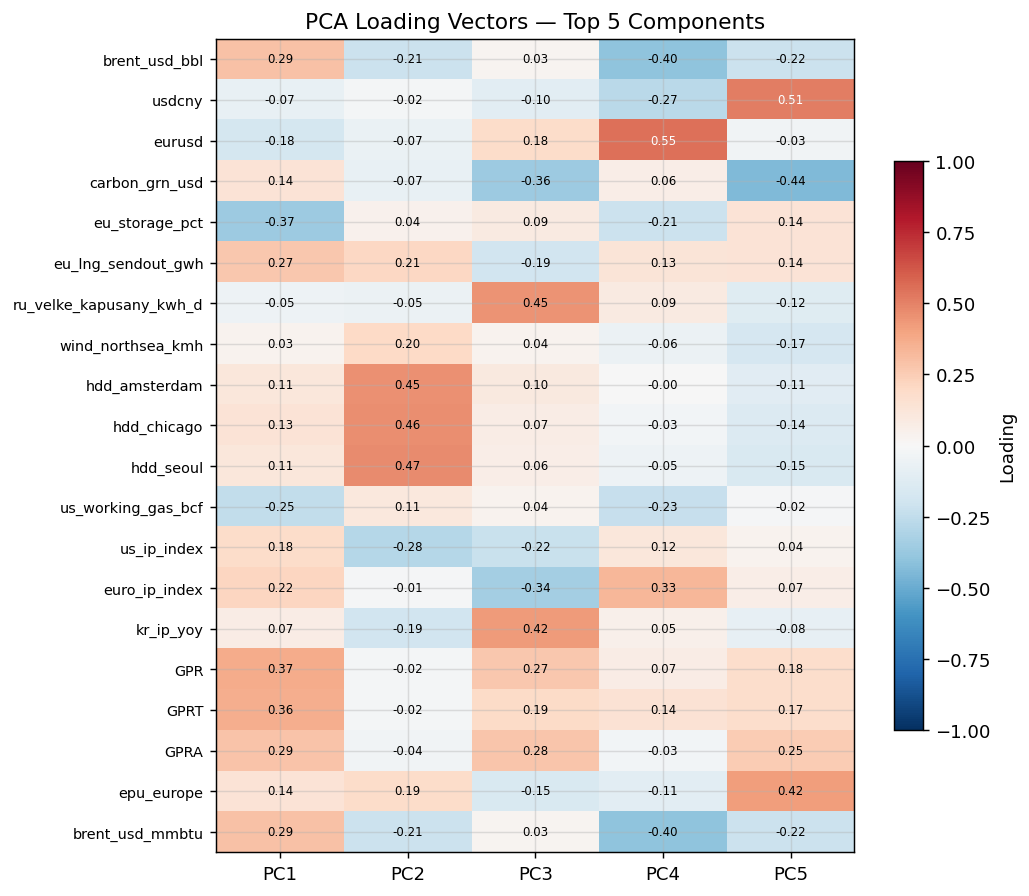

In [8]:
# Fit PCA with K components
pca = PCA(n_components=K_CHOSEN, random_state=42)
PC_train = pca.fit_transform(X_tr_scaled)   # (n_train, K)
PC_test  = pca.transform(X_te_scaled)        # (n_test,  K)

PC_labels = [f'PC{i+1}' for i in range(K_CHOSEN)]
df_PC_train = pd.DataFrame(PC_train, index=X_train_clean.index, columns=PC_labels)
df_PC_test  = pd.DataFrame(PC_test,  index=X_test_clean.index,  columns=PC_labels)

# Loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=PC_labels
)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(6, len(FEATURE_COLS)*0.35)))
im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.7, label='Loading')
ax.set_xticks(range(K_CHOSEN))
ax.set_xticklabels(PC_labels)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=8)

# Annotate values
for i in range(len(FEATURE_COLS)):
    for j in range(K_CHOSEN):
        val = loadings.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5,
                color='white' if abs(val) > 0.5 else 'black')

ax.set_title(f'PCA Loading Vectors — Top {K_CHOSEN} Components', fontsize=12)
plt.tight_layout()
plt.savefig('png/m3_fig02_loadings.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Economic interpretation of loading vectors

Inspect the heatmap above and complete this table after running:

| Component | Top positive loadings | Top negative loadings | Economic theme |
|-----------|----------------------|----------------------|----------------|
| PC1 | brent, carbon, GPR… | ru_velke_kapusany… | Global energy price level / supply shock |
| PC2 | eu_storage_pct, hdd_amsterdam… | eu_lng_sendout… | EU seasonal demand–storage balance |
| PC3 | GPR, GPRT, GPRA… | epu_europe… | Geopolitical risk |
| PC4 | us_ip, kr_ip, euro_ip… | | Industrial demand cycle |
| PC5 | wind_northsea, hdd_chicago… | | Renewables / US weather |

*Fill in actual values after running the heatmap.*

In [9]:
# Print top-3 positive and negative loadings per component
print('=== Top loadings per PC ===')
for pc in PC_labels:
    s = loadings[pc].abs().sort_values(ascending=False)
    top_pos = loadings.loc[loadings[pc] > 0, pc].nlargest(3).index.tolist()
    top_neg = loadings.loc[loadings[pc] < 0, pc].nsmallest(3).index.tolist()
    print(f'\n{pc} (var={pca.explained_variance_ratio_[PC_labels.index(pc)]*100:.1f}%):')
    print(f'  + {top_pos}')
    print(f'  – {top_neg}')

=== Top loadings per PC ===

PC1 (var=23.7%):
  + ['GPR', 'GPRT', 'brent_usd_mmbtu']
  – ['eu_storage_pct', 'us_working_gas_bcf', 'eurusd']

PC2 (var=16.7%):
  + ['hdd_seoul', 'hdd_chicago', 'hdd_amsterdam']
  – ['us_ip_index', 'brent_usd_mmbtu', 'brent_usd_bbl']

PC3 (var=11.0%):
  + ['ru_velke_kapusany_kwh_d', 'kr_ip_yoy', 'GPRA']
  – ['carbon_grn_usd', 'euro_ip_index', 'us_ip_index']

PC4 (var=9.6%):
  + ['eurusd', 'euro_ip_index', 'GPRT']
  – ['brent_usd_bbl', 'brent_usd_mmbtu', 'usdcny']

PC5 (var=8.4%):
  + ['usdcny', 'epu_europe', 'GPRA']
  – ['carbon_grn_usd', 'brent_usd_mmbtu', 'brent_usd_bbl']


## 4. Principal Component Regression (PCR)

Regress each spread on PC1…PCK using OLS with HC3 heteroscedasticity-robust
standard errors. Two target spreads: TTF–HH and TTF–JKM.

In [10]:
def fit_pcr(y: pd.Series, X_pc: pd.DataFrame, label: str) -> dict:
    """OLS with HC3 robust SEs. Returns model + diagnostics."""
    X_sm = sm.add_constant(X_pc)
    model = sm.OLS(y, X_sm).fit(cov_type='HC3')
    resid = model.resid
    dw    = durbin_watson(resid)
    bp_lm, bp_p, _, _ = het_breuschpagan(resid, X_sm)
    print(f'\n── {label} ────────────────────────────────────────────────')
    print(f'  R²        = {model.rsquared:.4f}  |  Adj-R² = {model.rsquared_adj:.4f}')
    print(f'  F-stat    = {model.fvalue:.2f}  (p={model.f_pvalue:.2e})')
    print(f'  DW stat   = {dw:.4f}  (2 = no autocorr; <2 positive autocorr)')
    print(f'  BP test   = LM {bp_lm:.2f}  (p={bp_p:.4f})')
    print(f'  {"HETEROSCEDASTIC" if bp_p < 0.05 else "Homoscedastic (BP)"} at 5%')
    print(f'  {"AUTOCORRELATED" if dw < 1.5 else "DW OK"} (DW rule-of-thumb < 1.5)')
    print(model.summary2().tables[1])  # coefficient table
    return {
        'model': model, 'resid': resid, 'dw': dw,
        'bp_lm': bp_lm, 'bp_p': bp_p,
        'r2': model.rsquared, 'adj_r2': model.rsquared_adj
    }

results = {}
for target in ['spread_ttf_hh', 'spread_ttf_jkm']:
    y_tr = y_train[target].dropna()
    X_pc = df_PC_train.loc[y_tr.index]  # align
    results[target] = fit_pcr(y_tr, X_pc, target)


── spread_ttf_hh ────────────────────────────────────────────────
  R²        = 0.5080  |  Adj-R² = 0.5060
  F-stat    = 135.90  (p=1.49e-114)
  DW stat   = 0.0710  (2 = no autocorr; <2 positive autocorr)
  BP test   = LM 213.35  (p=0.0000)
  HETEROSCEDASTIC at 5%
  AUTOCORRELATED (DW rule-of-thumb < 1.5)
           Coef.  Std.Err.          z         P>|z|     [0.025     0.975]
const  15.472637  0.254288  60.846823  0.000000e+00  14.974241  15.971033
PC1     1.489335  0.130293  11.430691  2.937624e-30   1.233966   1.744704
PC2     0.115143  0.135898   0.847276  3.968415e-01  -0.151212   0.381497
PC3    -4.031586  0.193953 -20.786422  5.743687e-96  -4.411726  -3.651445
PC4    -3.662266  0.188217 -19.457633  2.511196e-84  -4.031165  -3.293367
PC5     2.273490  0.226312  10.045841  9.582708e-24   1.829928   2.717053

── spread_ttf_jkm ────────────────────────────────────────────────
  R²        = 0.3749  |  Adj-R² = 0.3723
  F-stat    = 82.11  (p=2.22e-74)
  DW stat   = 0.2535  (2 = no a

## 5. Regression Diagnostics

Required by M3 rubric: residual scatter (homoscedasticity), multicollinearity,
temporal autocorrelation.

### 5.1 Residual diagnostic plots

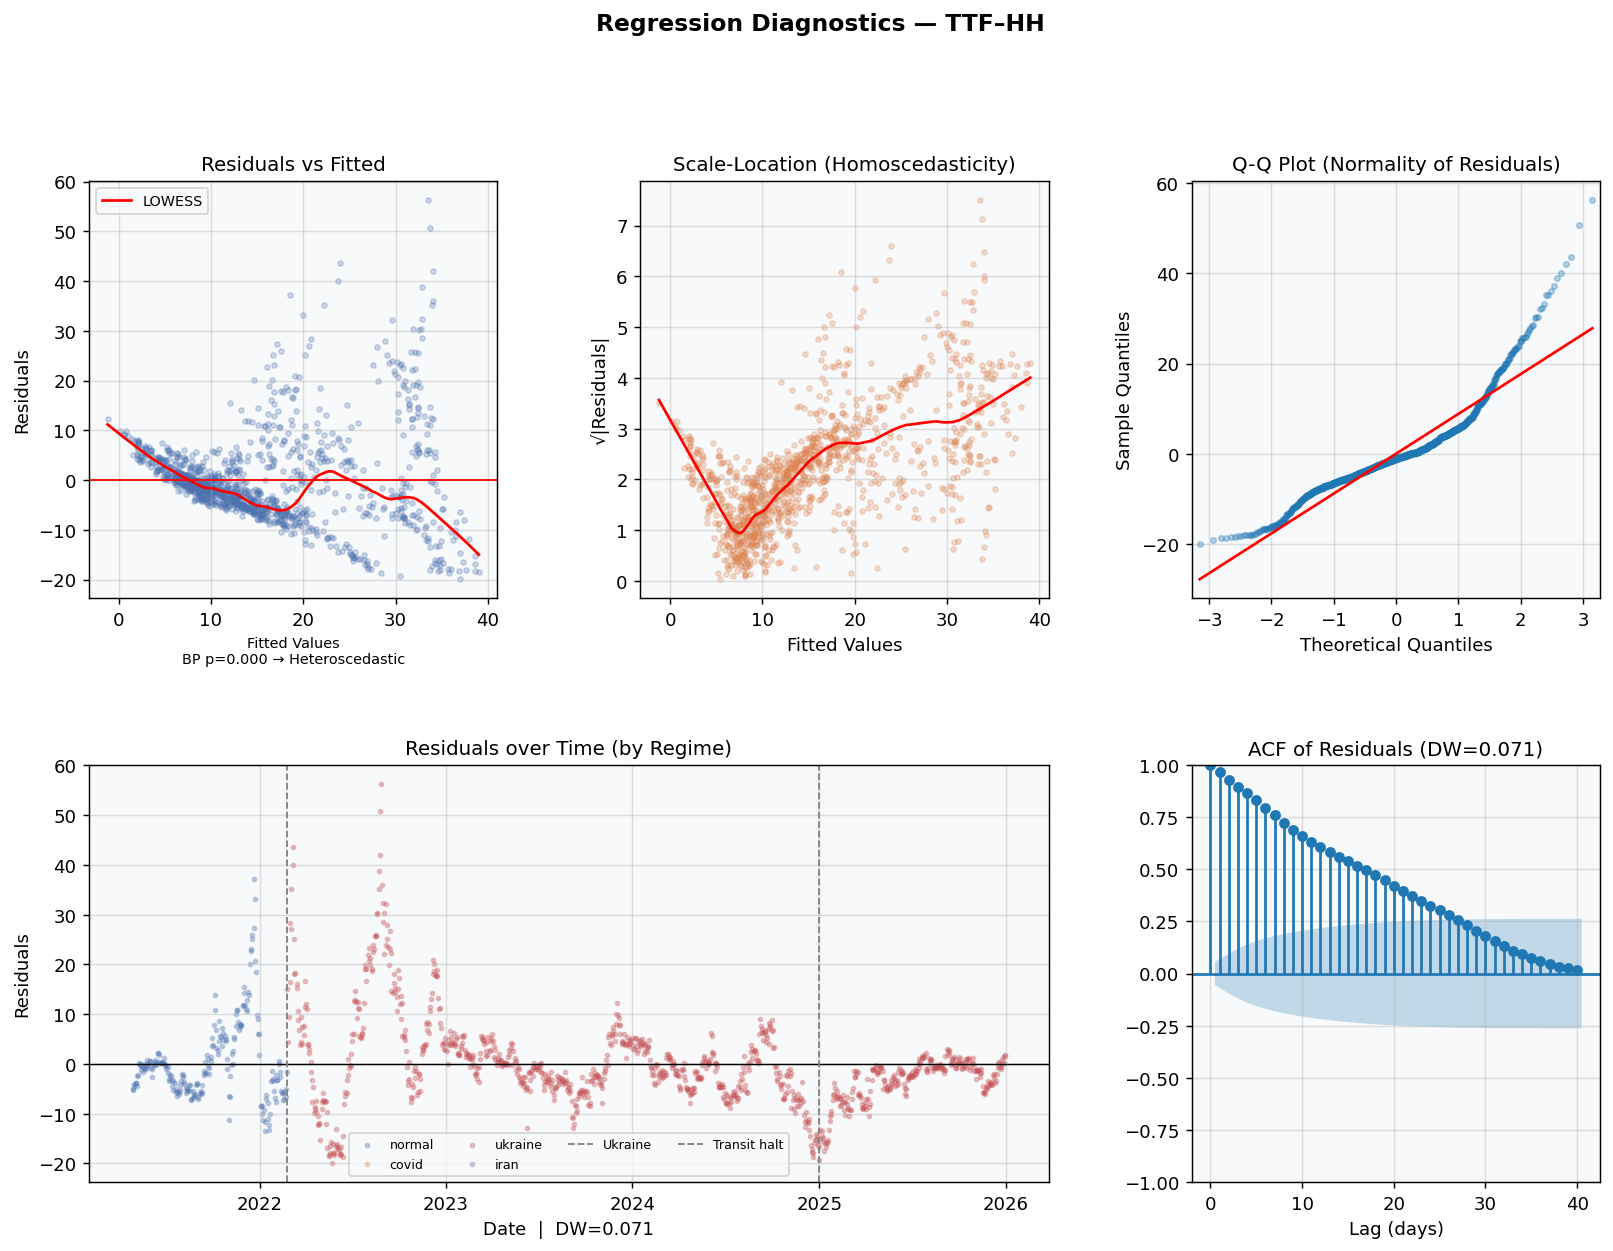

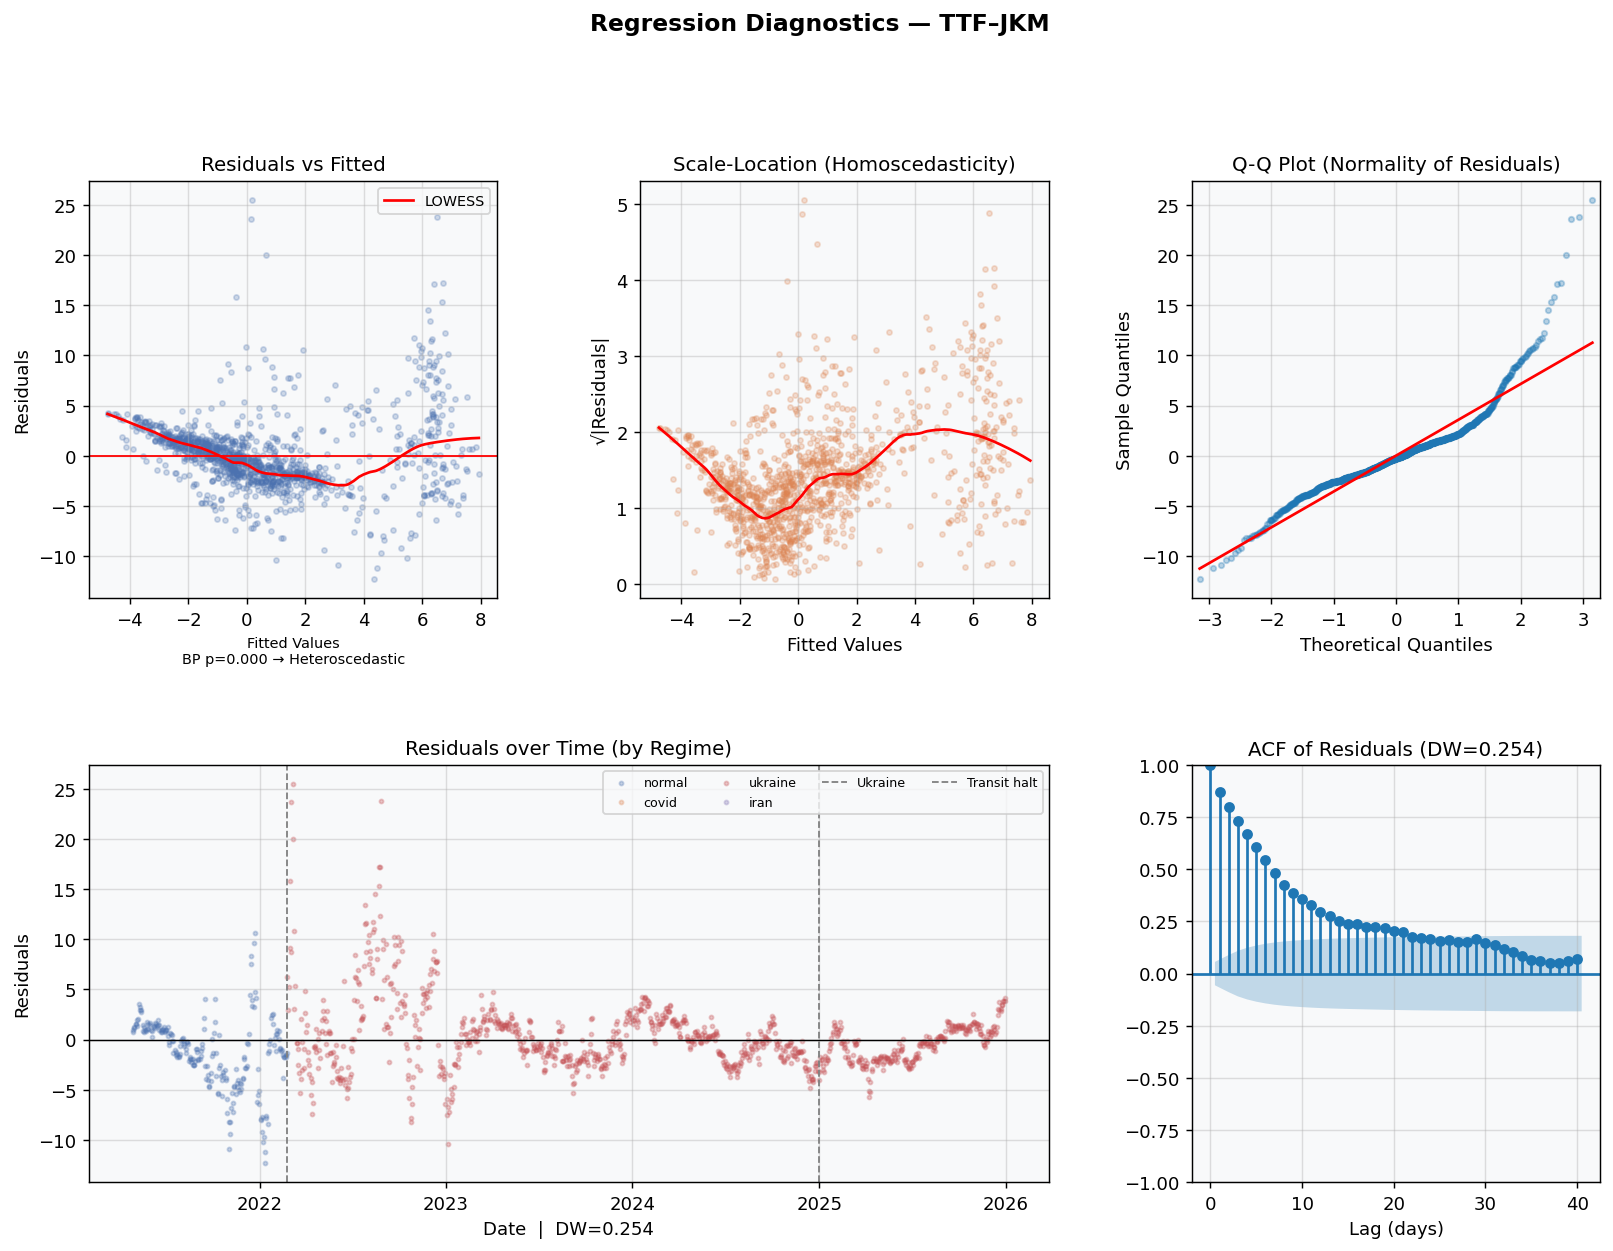

In [11]:
def plot_residual_diagnostics(result: dict, target_label: str, fig_prefix: str):
    resid  = result['resid']
    model  = result['model']
    fitted = model.fittedvalues

    fig = plt.figure(figsize=(15, 10))
    gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── 1. Residuals vs Fitted ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(fitted, resid, alpha=0.25, s=8, color='#4c72b0', rasterized=True)
    ax1.axhline(0, color='red', linewidth=1)
    # LOWESS smoother
    lo = sm.nonparametric.lowess(resid.values, fitted.values, frac=0.15)
    ax1.plot(lo[:,0], lo[:,1], color='red', linewidth=1.5, label='LOWESS')
    ax1.set_xlabel('Fitted Values')
    ax1.set_ylabel('Residuals')
    ax1.set_title('Residuals vs Fitted')
    ax1.legend(fontsize=8)
    bp_str = f"BP p={result['bp_p']:.3f} → {'Heteroscedastic' if result['bp_p']<0.05 else 'OK'}"
    ax1.set_xlabel(f'Fitted Values\n{bp_str}', fontsize=8)

    # ── 2. Scale-Location ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    sqrt_abs_resid = np.sqrt(np.abs(resid))
    ax2.scatter(fitted, sqrt_abs_resid, alpha=0.25, s=8, color='#dd8452', rasterized=True)
    lo2 = sm.nonparametric.lowess(sqrt_abs_resid.values, fitted.values, frac=0.15)
    ax2.plot(lo2[:,0], lo2[:,1], color='red', linewidth=1.5)
    ax2.set_xlabel('Fitted Values')
    ax2.set_ylabel('√|Residuals|')
    ax2.set_title('Scale-Location (Homoscedasticity)')

    # ── 3. Q-Q Plot ───────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    sm.qqplot(resid, line='s', ax=ax3, alpha=0.3, markersize=3)
    ax3.set_title('Q-Q Plot (Normality of Residuals)')

    # ── 4. Residuals over time ────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 0:2])
    regime_map = df.loc[resid.index, 'regime']
    for regime, color in REGIME_COLORS.items():
        mask = regime_map == regime
        ax4.scatter(resid.index[mask], resid[mask],
                    alpha=0.3, s=5, color=color, label=regime, rasterized=True)
    ax4.axhline(0, color='black', linewidth=0.8)
    for vdate, vlabel in [(UKRAINE_DATE,'Ukraine'), (TRANSIT_HALT,'Transit halt')]:
        ax4.axvline(pd.Timestamp(vdate), color='grey', linestyle='--',
                    linewidth=1, label=vlabel)
    ax4.set_xlabel(f'Date  |  DW={result["dw"]:.3f}')
    ax4.set_ylabel('Residuals')
    ax4.set_title('Residuals over Time (by Regime)')
    ax4.legend(fontsize=7, ncol=4)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # ── 5. ACF of residuals ───────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    plot_acf(resid, lags=40, ax=ax5, alpha=0.05)
    ax5.set_title(f'ACF of Residuals (DW={result["dw"]:.3f})')
    ax5.set_xlabel('Lag (days)')

    fig.suptitle(f'Regression Diagnostics — {target_label}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(f'png/{fig_prefix}.png', bbox_inches='tight', dpi=150)
    plt.show()

plot_residual_diagnostics(results['spread_ttf_hh'],  'TTF–HH',  'm3_fig03_diag_ttf_hh')
plot_residual_diagnostics(results['spread_ttf_jkm'], 'TTF–JKM', 'm3_fig04_diag_ttf_jkm')

### 5.2 Multicollinearity — VIF on raw features (motivation) vs PCs (proof)

VIF on raw features motivates PCA. VIF on the K principal components must be ~1
by construction (they are orthogonal) — this proves the multicollinearity is resolved.

In [12]:
def compute_vif(X: pd.DataFrame, label: str):
    """Compute VIF for each column in X."""
    X_c = sm.add_constant(X)
    vif = pd.DataFrame()
    vif['Feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X_c.values, i+1)
                  for i in range(X.shape[1])]
    vif = vif.sort_values('VIF', ascending=False)
    print(f'\n── VIF: {label} ──────────────────────────────────────────')
    print(vif.to_string(index=False))
    return vif

# VIF on raw (z-scored) features — expect high values for GPR family and IP
vif_raw = compute_vif(X_train_clean.dropna(), 'Raw features (motivation for PCA)')

# VIF on principal components — must be ≈1
vif_pcs = compute_vif(df_PC_train, f'Principal Components K={K_CHOSEN} (proof)')


── VIF: Raw features (motivation for PCA) ──────────────────────────────────────────
                Feature       VIF
          brent_usd_bbl       inf
        brent_usd_mmbtu       inf
                    GPR 71.717154
                   GPRT 41.082629
         eu_storage_pct 22.990646
     us_working_gas_bcf 13.940625
                   GPRA 11.373580
              hdd_seoul  5.441749
            hdd_chicago  4.654363
          hdd_amsterdam  3.811208
                 eurusd  3.599138
         carbon_grn_usd  3.080001
                 usdcny  2.757402
            us_ip_index  2.300476
          euro_ip_index  2.204667
              kr_ip_yoy  2.172413
             epu_europe  2.171463
     eu_lng_sendout_gwh  2.074266
ru_velke_kapusany_kwh_d  1.717500
      wind_northsea_kmh  1.238061

── VIF: Principal Components K=5 (proof) ──────────────────────────────────────────
Feature  VIF
    PC1  1.0
    PC2  1.0
    PC3  1.0
    PC4  1.0
    PC5  1.0


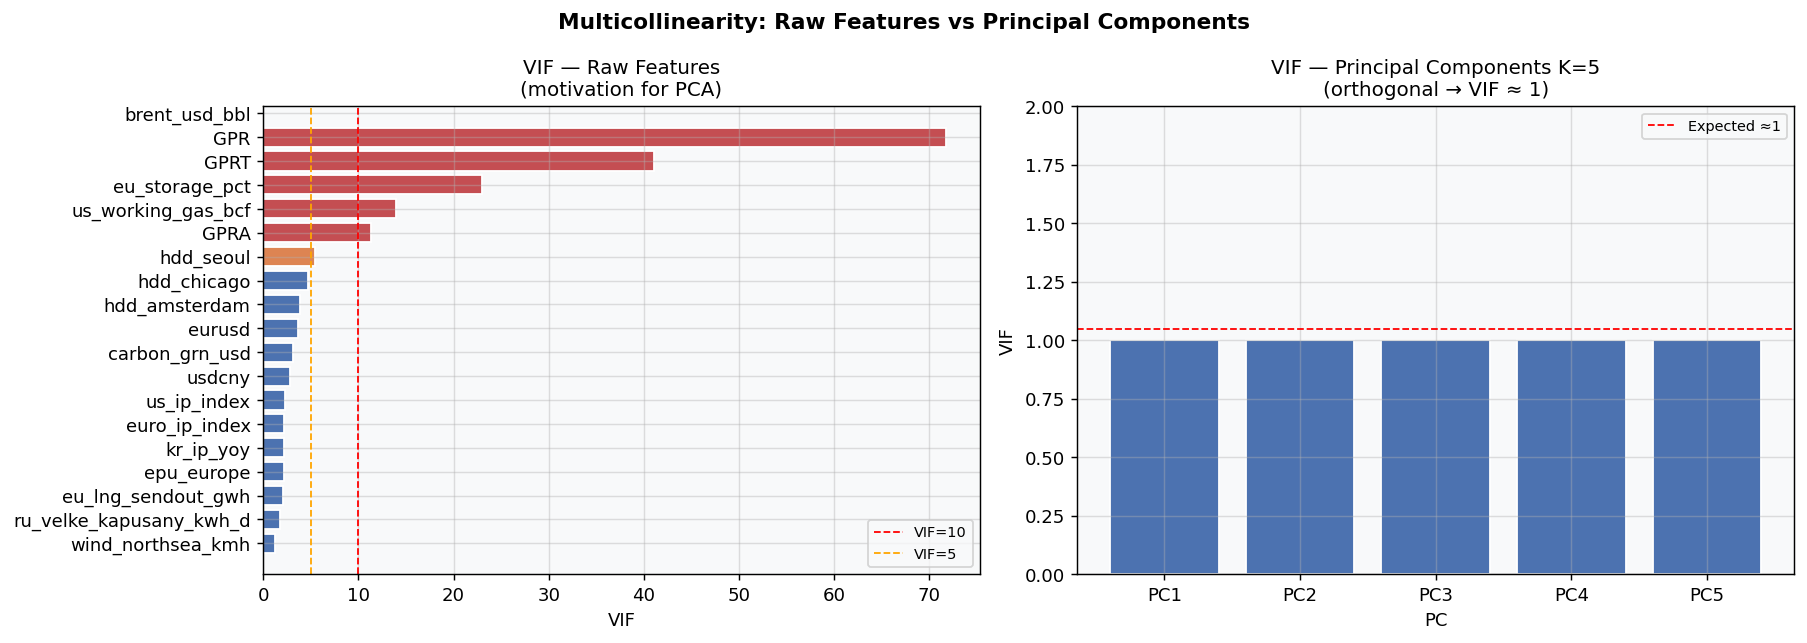

In [13]:
# ── Bar chart comparing VIF: raw vs PCs ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
vif_raw_sorted = vif_raw.sort_values('VIF', ascending=True)
colors_raw = ['#c44e52' if v > 10 else '#dd8452' if v > 5 else '#4c72b0'
              for v in vif_raw_sorted['VIF']]
ax.barh(vif_raw_sorted['Feature'], vif_raw_sorted['VIF'],
        color=colors_raw, edgecolor='white')
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='VIF=10')
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='VIF=5')
ax.set_xlabel('VIF')
ax.set_title('VIF — Raw Features\n(motivation for PCA)')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.bar(vif_pcs['Feature'], vif_pcs['VIF'], color='#4c72b0', edgecolor='white')
ax2.axhline(1.05, color='red', linestyle='--', linewidth=1, label='Expected ≈1')
ax2.set_xlabel('PC')
ax2.set_ylabel('VIF')
ax2.set_title(f'VIF — Principal Components K={K_CHOSEN}\n(orthogonal → VIF ≈ 1)')
ax2.legend(fontsize=8)
ax2.set_ylim(0, max(2, vif_pcs['VIF'].max() * 1.2))

fig.suptitle('Multicollinearity: Raw Features vs Principal Components',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('png/m3_fig05_vif.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Structural Break Tests — Chow Test

Chow test asks: do the PCR coefficients shift significantly at a known date?

- **2022-02-24** (Ukraine invasion) — positive control (we expect a break)
- **2026-01-01** (Iran/Hormuz) — the open question (does the new regime break the structure?)

In [14]:
def chow_test(y: pd.Series, X_pc: pd.DataFrame,
              break_date: str, label: str) -> dict:
    """
    Chow structural break test.

    H0: coefficients are the same before and after break_date.
    Test stat: F = [(RSS_pool - RSS1 - RSS2) / K] / [(RSS1+RSS2) / (n-2K)]
    where K = number of regressors (including const).
    """
    bd = pd.Timestamp(break_date)
    X_c = sm.add_constant(X_pc)

    # Align y and X
    idx = y.dropna().index.intersection(X_c.index)
    y_  = y.loc[idx]
    X_  = X_c.loc[idx]

    mask_pre  = X_.index < bd
    mask_post = X_.index >= bd

    n_pre  = mask_pre.sum()
    n_post = mask_post.sum()
    K      = X_.shape[1]  # includes const

    if n_pre < K + 5 or n_post < K + 5:
        print(f'  [{label}] Insufficient obs around {break_date} (pre={n_pre}, post={n_post})')
        return {}

    # Pooled OLS
    m_pool = sm.OLS(y_, X_).fit()
    RSS_pool = m_pool.ssr

    # Sub-period OLS
    m_pre  = sm.OLS(y_[mask_pre],  X_[mask_pre]).fit()
    m_post = sm.OLS(y_[mask_post], X_[mask_post]).fit()
    RSS1, RSS2 = m_pre.ssr, m_post.ssr

    n = len(y_)
    F_stat = ((RSS_pool - RSS1 - RSS2) / K) / ((RSS1 + RSS2) / (n - 2*K))
    from scipy.stats import f as f_dist
    p_val = 1 - f_dist.cdf(F_stat, K, n - 2*K)

    print(f'\n── Chow test | {label} | Break: {break_date} ────────────────')
    print(f'  n_pre={n_pre}, n_post={n_post}  |  K={K}')
    print(f'  RSS_pool={RSS_pool:.2f}  RSS_pre={RSS1:.2f}  RSS_post={RSS2:.2f}')
    print(f'  F({K}, {n-2*K}) = {F_stat:.4f}  |  p-value = {p_val:.4e}')
    conclusion = 'BREAK DETECTED' if p_val < 0.05 else 'No significant break'
    print(f'  → {conclusion} at 5% significance')

    return {
        'break_date': break_date,
        'F': F_stat, 'p': p_val,
        'r2_pre': m_pre.rsquared, 'r2_post': m_post.rsquared,
        'coef_pre': m_pre.params, 'coef_post': m_post.params
    }

chow_results = {}
for target in ['spread_ttf_hh', 'spread_ttf_jkm']:
    y_full = df[target]  # native units, full sample
    X_pc_full = pd.concat([df_PC_train, df_PC_test])  # all dates
    print(f'\n╔══ {target} ═══════════════════════════════════════════════╗')
    for bdate, blabel in [(UKRAINE_DATE, 'Ukraine (positive control)'),
                           (IRAN_DATE,    'Iran/Hormuz (open question)')]:
        key = f'{target}_{bdate}'
        chow_results[key] = chow_test(y_full, X_pc_full, bdate, f'{target} | {blabel}')


╔══ spread_ttf_hh ═══════════════════════════════════════════════╗

── Chow test | spread_ttf_hh | Ukraine (positive control) | Break: 2022-02-24 ────────────────
  n_pre=217, n_post=1113  |  K=6
  RSS_pool=96164.59  RSS_pre=5562.51  RSS_post=81748.29
  F(6, 1318) = 22.2754  |  p-value = 1.1102e-16
  → BREAK DETECTED at 5% significance

── Chow test | spread_ttf_hh | Iran/Hormuz (open question) | Break: 2026-01-01 ────────────────
  n_pre=1222, n_post=108  |  K=6
  RSS_pool=96164.59  RSS_pre=95478.20  RSS_post=91.34
  F(6, 1318) = 1.3677  |  p-value = 2.2428e-01
  → No significant break at 5% significance

╔══ spread_ttf_jkm ═══════════════════════════════════════════════╗

── Chow test | spread_ttf_jkm | Ukraine (positive control) | Break: 2022-02-24 ────────────────
  n_pre=217, n_post=1113  |  K=6
  RSS_pool=16616.97  RSS_pre=1650.07  RSS_post=12729.05
  F(6, 1318) = 34.1871  |  p-value = 1.1102e-16
  → BREAK DETECTED at 5% significance

── Chow test | spread_ttf_jkm | Iran/Hormuz 

### 6.1 Coefficient Shift Plot — pre vs post break

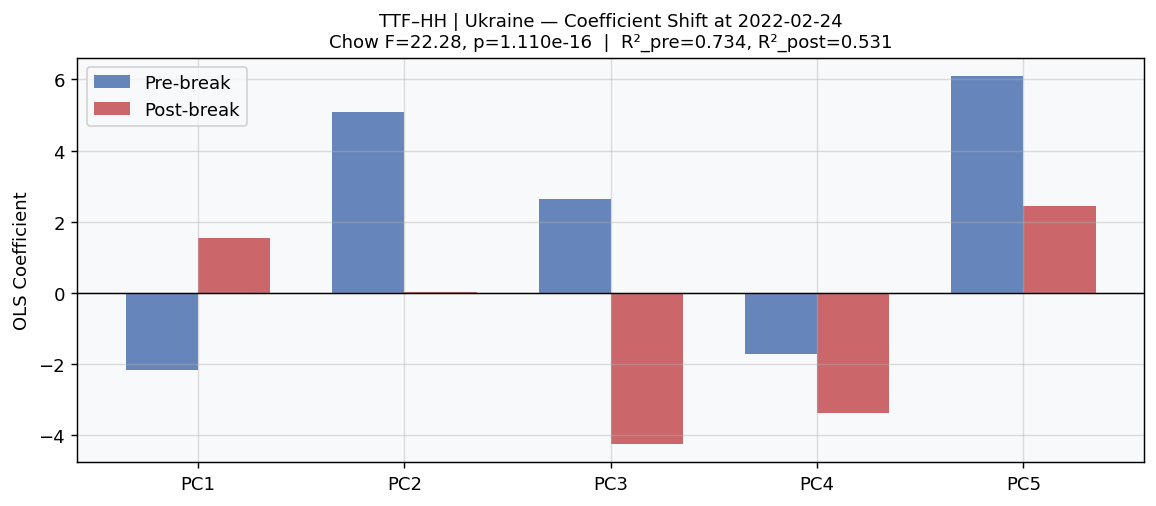

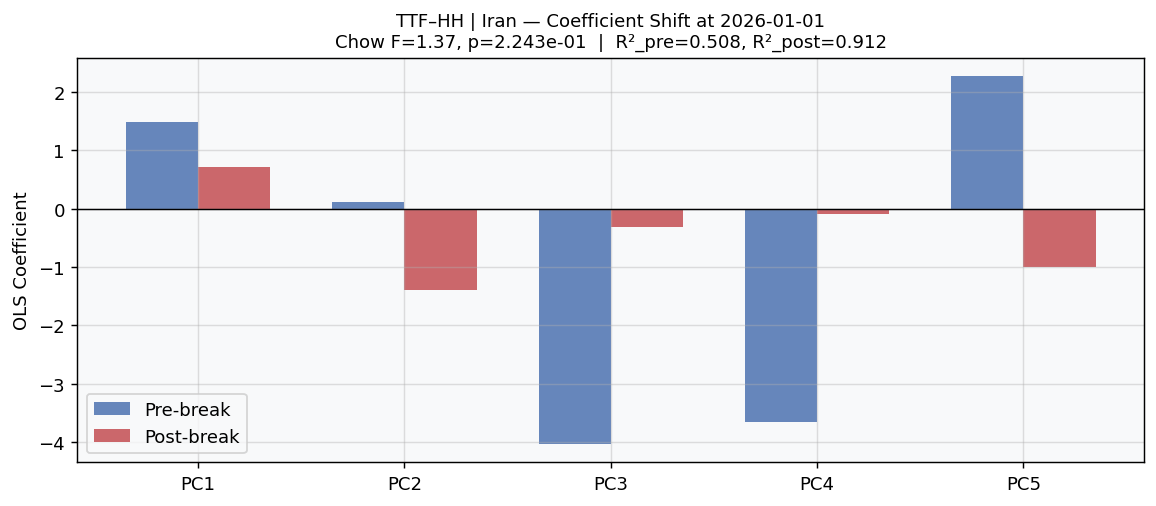

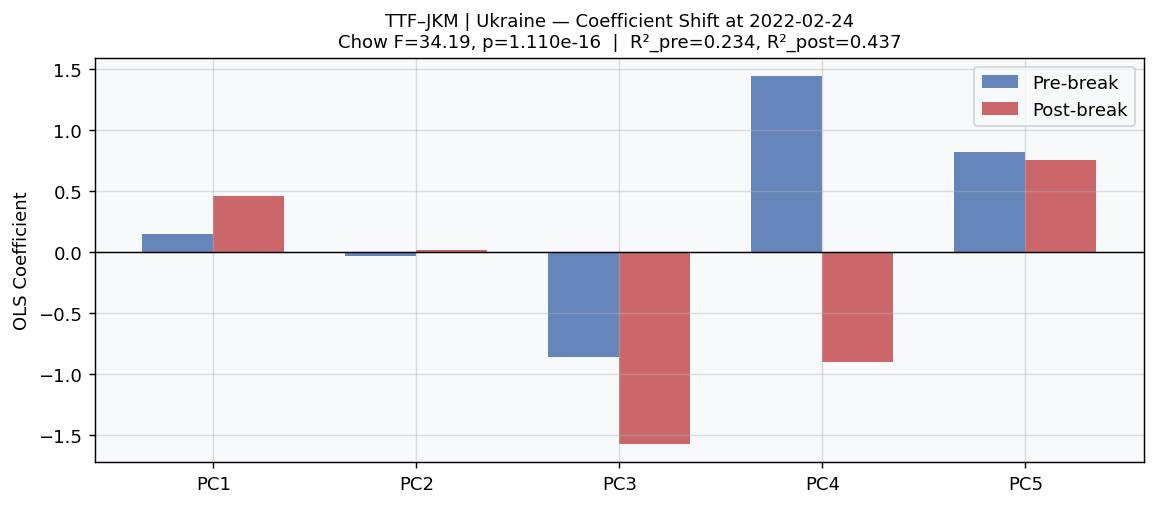

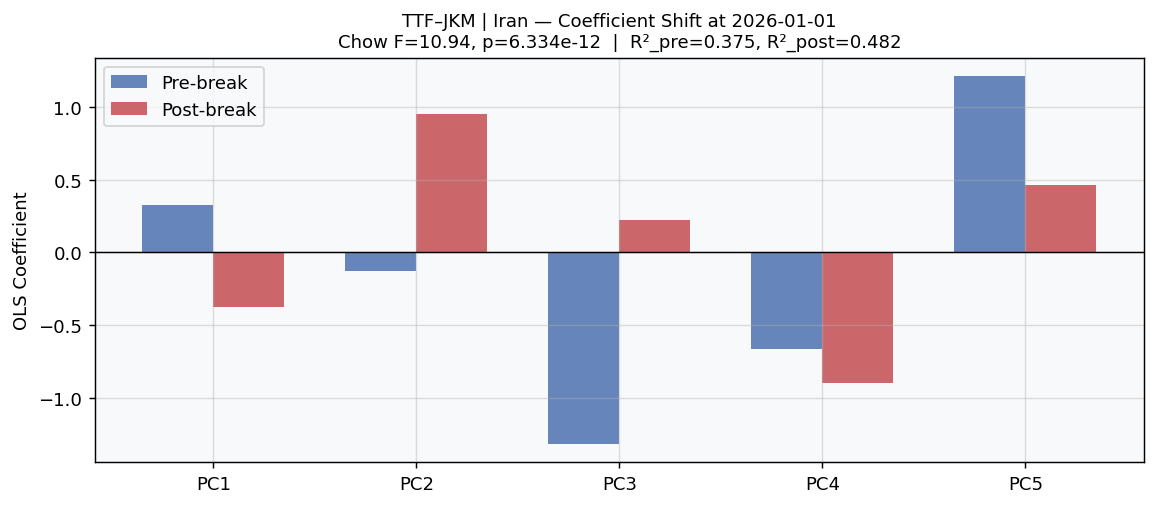

In [15]:
def plot_coefficient_shift(chow_res: dict, target_label: str, fig_name: str):
    if not chow_res:
        return
    coef_pre  = chow_res['coef_pre'].drop('const', errors='ignore')
    coef_post = chow_res['coef_post'].drop('const', errors='ignore')
    labels    = coef_pre.index

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 4))
    bars_pre  = ax.bar(x - width/2, coef_pre.values,  width, label='Pre-break',
                       color='#4c72b0', alpha=0.85)
    bars_post = ax.bar(x + width/2, coef_post.values, width, label='Post-break',
                       color='#c44e52', alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('OLS Coefficient')
    ax.set_title(
        f'{target_label} — Coefficient Shift at {chow_res["break_date"]}\n'
        f'Chow F={chow_res["F"]:.2f}, p={chow_res["p"]:.3e}  |  '
        f'R²_pre={chow_res["r2_pre"]:.3f}, R²_post={chow_res["r2_post"]:.3f}',
        fontsize=10
    )
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'png/{fig_name}.png', bbox_inches='tight', dpi=150)
    plt.show()

for target, tl in [('spread_ttf_hh','TTF–HH'), ('spread_ttf_jkm','TTF–JKM')]:
    for bdate, blabel, fn_sfx in [(UKRAINE_DATE, 'Ukraine', 'ukr'),
                                   (IRAN_DATE,    'Iran',    'iran')]:
        key = f'{target}_{bdate}'
        if key in chow_results and chow_results[key]:
            plot_coefficient_shift(
                chow_results[key],
                f'{tl} | {blabel}',
                f'm3_fig06_coef_{target.split("_")[2]}_{fn_sfx}'
            )

## 7. Out-of-Sample Projection — 2026 Test Window

In [16]:
oos_summary = {}

for target in ['spread_ttf_hh', 'spread_ttf_jkm']:
    model = results[target]['model']
    y_te  = y_test[target].dropna()
    X_te  = df_PC_test.loc[y_te.index]
    X_te_sm = sm.add_constant(X_te)

    # Ensure column alignment with train model
    X_te_sm = X_te_sm.reindex(columns=model.model.exog_names, fill_value=0)

    y_pred  = model.predict(X_te_sm)
    resid_oos = y_te - y_pred

    r2_oos   = r2_score(y_te, y_pred)
    rmse_oos = np.sqrt(mean_squared_error(y_te, y_pred))
    dw_oos   = durbin_watson(resid_oos)

    oos_summary[target] = {
        'r2_train': results[target]['r2'],
        'r2_oos':   r2_oos,
        'rmse_oos': rmse_oos,
        'dw_oos':   dw_oos,
        'y_te': y_te, 'y_pred': y_pred, 'resid': resid_oos
    }

    print(f'\n── OOS: {target} ────────────────────────────────────────────')
    print(f'  R² train = {results[target]["r2"]:.4f}')
    print(f'  R² OOS   = {r2_oos:.4f}')
    print(f'  RMSE OOS = {rmse_oos:.4f} USD/MMBtu')
    print(f'  DW OOS   = {dw_oos:.4f}')


── OOS: spread_ttf_hh ────────────────────────────────────────────
  R² train = 0.5080
  R² OOS   = 0.2876
  RMSE OOS = 2.6147 USD/MMBtu
  DW OOS   = 0.2785

── OOS: spread_ttf_jkm ────────────────────────────────────────────
  R² train = 0.3749
  R² OOS   = -2.3555
  RMSE OOS = 3.2924 USD/MMBtu
  DW OOS   = 0.0646


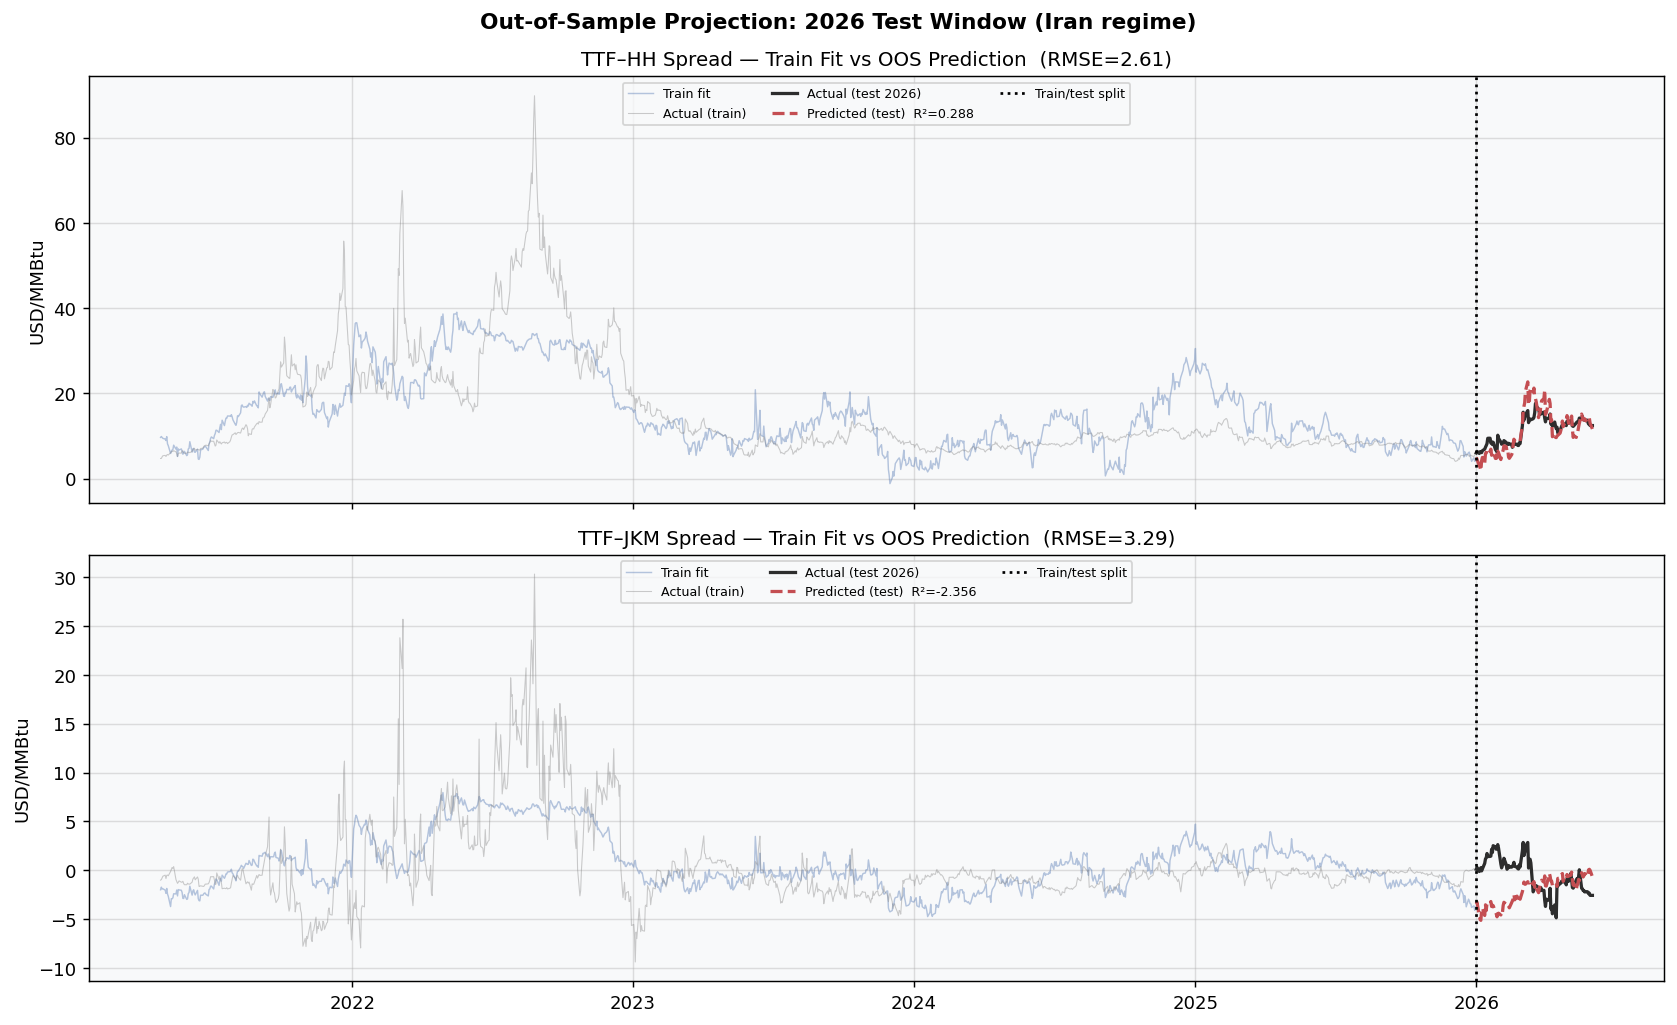

In [17]:
# ── Actual vs Predicted — OOS ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

spread_labels = {'spread_ttf_hh': 'TTF–HH', 'spread_ttf_jkm': 'TTF–JKM'}

for ax, target in zip(axes, ['spread_ttf_hh', 'spread_ttf_jkm']):
    tl = spread_labels[target]
    oos = oos_summary[target]

    # Train: actual (light)
    ax.plot(df_PC_train.index,
            results[target]['model'].fittedvalues,
            color='#4c72b0', alpha=0.4, linewidth=0.8, label='Train fit')
    ax.plot(y_train[target].dropna().index,
            y_train[target].dropna(),
            color='grey', alpha=0.4, linewidth=0.6, label='Actual (train)')

    # Test: actual vs predicted
    ax.plot(oos['y_te'].index, oos['y_te'],
            color='#2d2d2d', linewidth=1.8, label='Actual (test 2026)')
    ax.plot(oos['y_pred'].index, oos['y_pred'],
            color='#c44e52', linewidth=1.8, linestyle='--',
            label=f'Predicted (test)  R²={oos["r2_oos"]:.3f}')

    ax.axvline(pd.Timestamp(TEST_START), color='black', linestyle=':',
               linewidth=1.5, label='Train/test split')
    ax.set_ylabel('USD/MMBtu')
    ax.set_title(f'{tl} Spread — Train Fit vs OOS Prediction  '
                 f'(RMSE={oos["rmse_oos"]:.2f})')
    ax.legend(fontsize=7, ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Out-of-Sample Projection: 2026 Test Window (Iran regime)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('png/m3_fig07_oos.png', bbox_inches='tight', dpi=150)
plt.show()

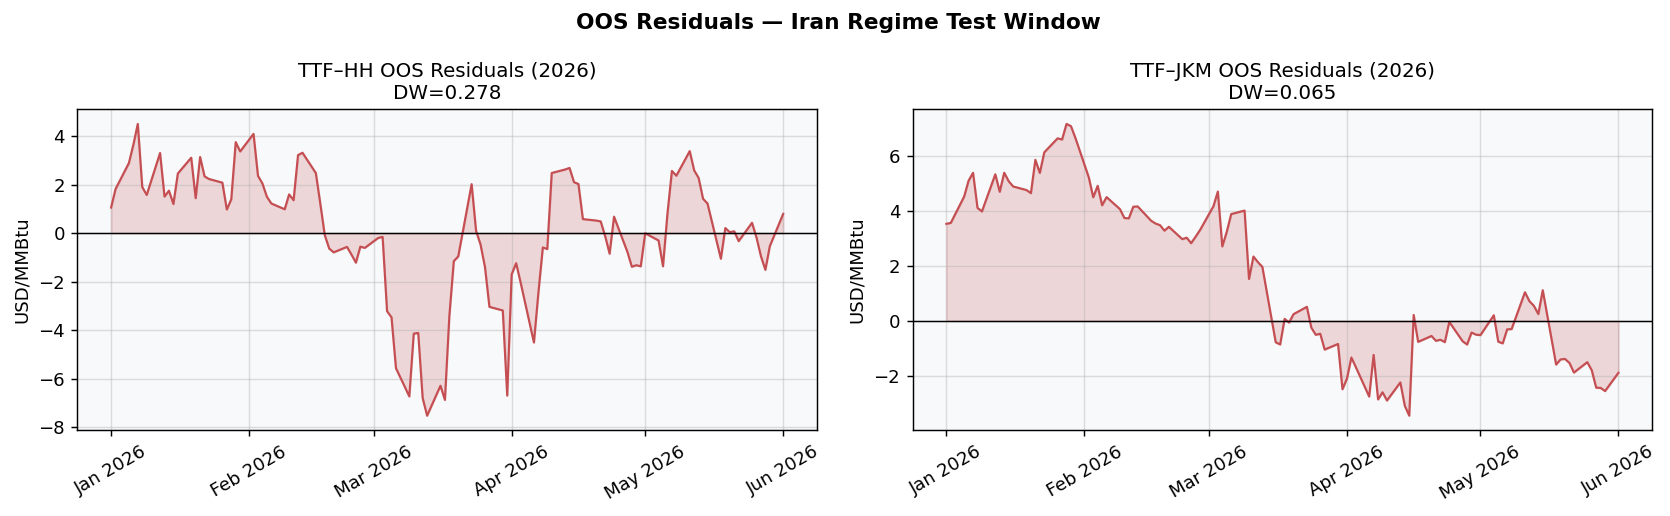

In [18]:
# ── OOS Residuals ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, target in zip(axes, ['spread_ttf_hh', 'spread_ttf_jkm']):
    tl  = spread_labels[target]
    oos = oos_summary[target]
    ax.plot(oos['resid'].index, oos['resid'],
            color='#c44e52', linewidth=1.2, label='OOS residual')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(oos['resid'].index, oos['resid'], 0,
                    alpha=0.2, color='#c44e52')
    ax.set_title(f'{tl} OOS Residuals (2026)\nDW={oos["dw_oos"]:.3f}')
    ax.set_ylabel('USD/MMBtu')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('OOS Residuals — Iran Regime Test Window',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('png/m3_fig08_oos_resid.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Summary Table — All Diagnostics

In [19]:
print('\n' + '='*72)
print('MILESTONE 3 DIAGNOSTIC SUMMARY')
print('='*72)

for target, tl in [('spread_ttf_hh','TTF–HH'), ('spread_ttf_jkm','TTF–JKM')]:
    res = results[target]
    oos = oos_summary[target]
    print(f'\n{tl}')
    print(f'  PCA K             = {K_CHOSEN}  ({cum_evr[K_CHOSEN-1]*100:.1f}% variance)')
    print(f'  R² (train)        = {res["r2"]:.4f}')
    print(f'  Adj-R² (train)    = {res["adj_r2"]:.4f}')
    print(f'  R² (OOS 2026)     = {oos["r2_oos"]:.4f}')
    print(f'  RMSE (OOS)        = {oos["rmse_oos"]:.4f} USD/MMBtu')
    print(f'  Durbin-Watson     = {res["dw"]:.4f}  (train)  {oos["dw_oos"]:.4f} (OOS)')
    print(f'  BP heterosced.    = LM {res["bp_lm"]:.2f}, p={res["bp_p"]:.3e} '
          f'→ {"HC3 SEs applied" if res["bp_p"]<0.05 else "Homoscedastic"}')
    print(f'  VIF on PCs        = ≈ 1 (orthogonal by construction)')
    for bdate, blabel in [(UKRAINE_DATE,'Ukraine'), (IRAN_DATE,'Iran')]:
        key = f'{target}_{bdate}'
        if key in chow_results and chow_results[key]:
            cr = chow_results[key]
            sig = 'BREAK' if cr['p'] < 0.05 else 'No break'
            print(f'  Chow {blabel:8s}   = F={cr["F"]:.2f}, p={cr["p"]:.3e} → {sig}')

print('\n' + '='*72)
print('Figures saved to png/ folder.')


MILESTONE 3 DIAGNOSTIC SUMMARY

TTF–HH
  PCA K             = 5  (69.4% variance)
  R² (train)        = 0.5080
  Adj-R² (train)    = 0.5060
  R² (OOS 2026)     = 0.2876
  RMSE (OOS)        = 2.6147 USD/MMBtu
  Durbin-Watson     = 0.0710  (train)  0.2785 (OOS)
  BP heterosced.    = LM 213.35, p=3.956e-44 → HC3 SEs applied
  VIF on PCs        = ≈ 1 (orthogonal by construction)
  Chow Ukraine    = F=22.28, p=1.110e-16 → BREAK
  Chow Iran       = F=1.37, p=2.243e-01 → No break

TTF–JKM
  PCA K             = 5  (69.4% variance)
  R² (train)        = 0.3749
  Adj-R² (train)    = 0.3723
  R² (OOS 2026)     = -2.3555
  RMSE (OOS)        = 3.2924 USD/MMBtu
  Durbin-Watson     = 0.2535  (train)  0.0646 (OOS)
  BP heterosced.    = LM 123.96, p=4.554e-25 → HC3 SEs applied
  VIF on PCs        = ≈ 1 (orthogonal by construction)
  Chow Ukraine    = F=34.19, p=1.110e-16 → BREAK
  Chow Iran       = F=10.94, p=6.334e-12 → BREAK

Figures saved to png/ folder.


## 9. Appendix — Regime-coloured PC trajectories

Visual aid for the presentation: how the first few PCs evolve across regimes.

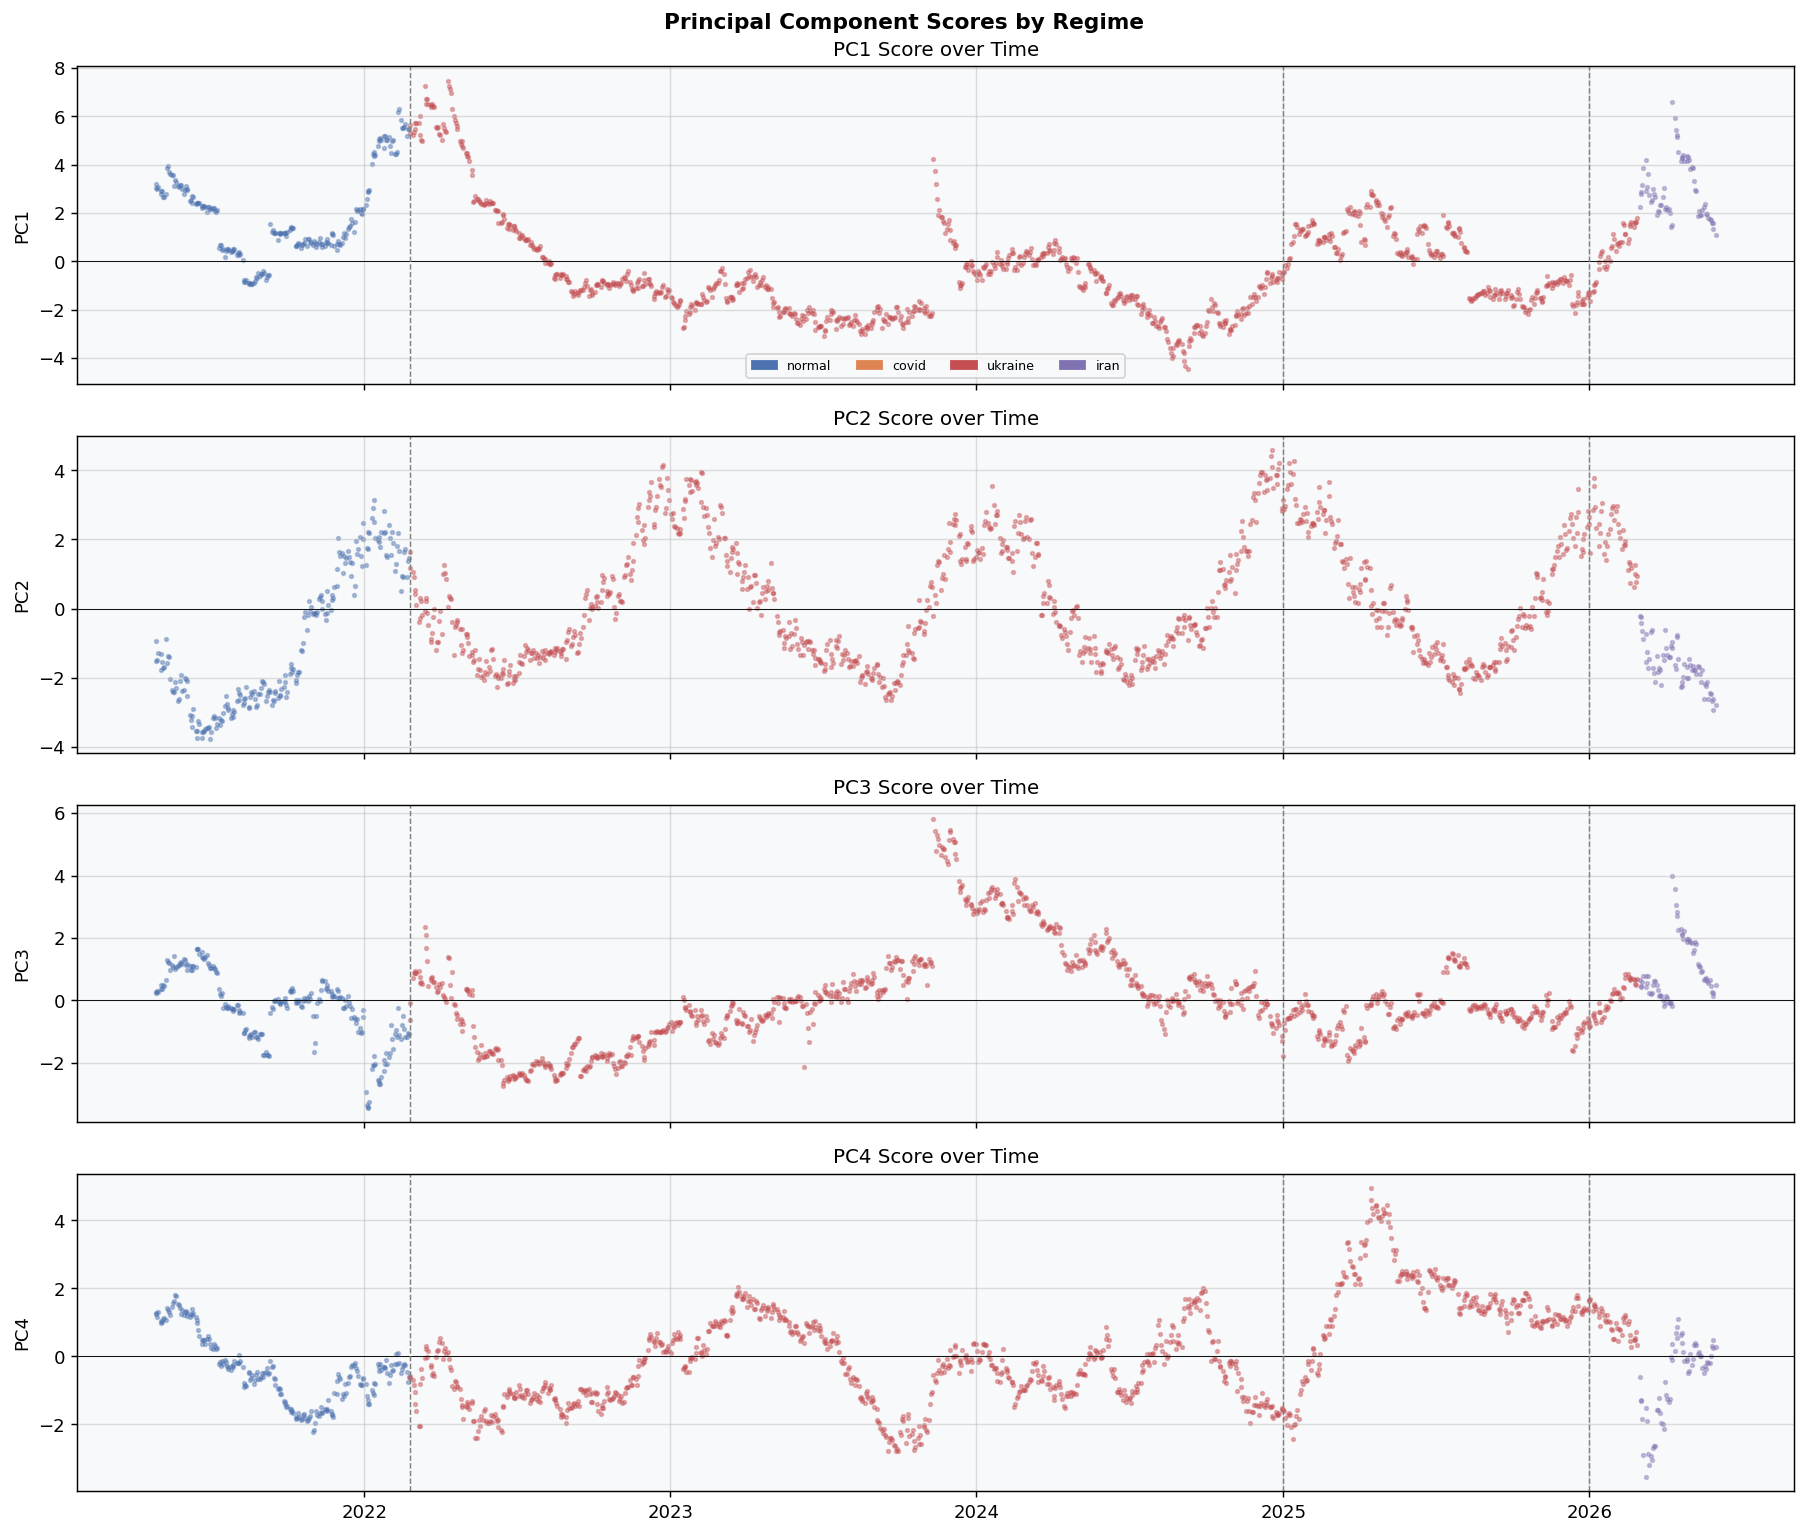

In [20]:
PC_all = pd.concat([df_PC_train, df_PC_test])
regime_all = df.loc[PC_all.index, 'regime']

n_pc_plot = min(4, K_CHOSEN)
fig, axes = plt.subplots(n_pc_plot, 1, figsize=(14, 3*n_pc_plot), sharex=True)
if n_pc_plot == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    pc_col = f'PC{i+1}'
    for regime, color in REGIME_COLORS.items():
        mask = regime_all == regime
        idx  = PC_all.index[mask]
        ax.scatter(idx, PC_all.loc[idx, pc_col],
                   s=4, alpha=0.4, color=color, label=regime, rasterized=True)
    ax.axhline(0, color='black', linewidth=0.5)
    for vdate in [UKRAINE_DATE, IRAN_DATE, TRANSIT_HALT]:
        ax.axvline(pd.Timestamp(vdate), color='grey', linestyle='--', linewidth=0.8)
    ax.set_ylabel(pc_col)
    ax.set_title(f'{pc_col} Score over Time')
    if i == 0:
        legend_handles = [mpatches.Patch(color=c, label=r)
                          for r, c in REGIME_COLORS.items()]
        ax.legend(handles=legend_handles, fontsize=7, ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Principal Component Scores by Regime', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('png/m3_fig09_pc_scores.png', bbox_inches='tight', dpi=150)
plt.show()